In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
print("Veri işleme, görselleştirme, performans değerlendirme ve ResNet50 tabanlı transfer öğrenme modeli için gerekli kütüphaneler başarıyla yüklendi.")

Veri işleme, görselleştirme, performans değerlendirme ve ResNet50 tabanlı transfer öğrenme modeli için gerekli kütüphaneler başarıyla yüklendi.


In [42]:
ORIGINAL_DIR = r"C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\archive"
FILTERED_DIR = r"C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 75
SEED = 42
LEARNING_RATE = 1e-4
CLASS_NAMES = ["benign", "malignant"]

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
print("Orijinal ve filtrelenmiş veri yolları ile eğitim parametreleri tanımlandı. Epoch değeri 75 seçilerek ödevde istenen minimum eğitim süresi sağlandı.")

Orijinal ve filtrelenmiş veri yolları ile eğitim parametreleri tanımlandı. Epoch değeri 75 seçilerek ödevde istenen minimum eğitim süresi sağlandı.


In [23]:
print("ORIGINAL_DIR var mı?:", os.path.exists(ORIGINAL_DIR))
print("train var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "train")))
print("valid var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "valid")))
print("test var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "test")))
print("train/benign var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "train", "benign")))
print("train/malignant var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "train", "malignant")))
print("valid/benign var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "valid", "benign")))
print("valid/malignant var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "valid", "malignant")))
print("test/benign var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "test", "benign")))
print("test/malignant var mı?:", os.path.exists(os.path.join(ORIGINAL_DIR, "test", "malignant")))

ORIGINAL_DIR var mı?: True
train var mı?: True
valid var mı?: True
test var mı?: True
train/benign var mı?: True
train/malignant var mı?: True
valid/benign var mı?: True
valid/malignant var mı?: True
test/benign var mı?: True
test/malignant var mı?: True


In [43]:
def collect_split_paths(base_dir, split_name, class_names):
    data = []

    for label in class_names:
        class_dir = os.path.join(base_dir, split_name, label)

        if not os.path.exists(class_dir):
            print(f"Bulunamadı: {class_dir}")
            continue

        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                file_path = os.path.join(class_dir, file_name)
                data.append([file_path, label])

    df = pd.DataFrame(data, columns=["filename", "label"])
    return df
    print("Train, valid ve test klasörlerindeki görüntü yollarını ve sınıf etiketlerini toplayan fonksiyon tanımlandı.")

In [46]:
def create_generators_from_splits(base_dir):
    train_df = collect_split_paths(base_dir, "train", CLASS_NAMES)
    val_df   = collect_split_paths(base_dir, "valid", CLASS_NAMES)
    test_df  = collect_split_paths(base_dir, "test", CLASS_NAMES)

    print("Train sayısı:", len(train_df))
    print(train_df["label"].value_counts() if len(train_df) > 0 else "Train boş")

    print("\nValid sayısı:", len(val_df))
    print(val_df["label"].value_counts() if len(val_df) > 0 else "Valid boş")

    print("\nTest sayısı:", len(test_df))
    print(test_df["label"].value_counts() if len(test_df) > 0 else "Test boş")

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=SEED
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen, test_gen


In [47]:
train_gen, val_gen, test_gen = create_generators_from_splits(ORIGINAL_DIR)

Train sayısı: 1184
label
malignant    802
benign       382
Name: count, dtype: int64

Valid sayısı: 339
label
malignant    229
benign       110
Name: count, dtype: int64

Test sayısı: 170
label
malignant    115
benign        55
Name: count, dtype: int64
Found 1184 validated image filenames belonging to 2 classes.
Found 339 validated image filenames belonging to 2 classes.
Found 170 validated image filenames belonging to 2 classes.


In [48]:
def build_resnet50_model(num_classes=2):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
    print("ImageNet ön eğitimli ResNet50 modeli transfer öğrenme amacıyla oluşturuldu ve yeni sınıflandırma katmanları eklendi.")

In [49]:
def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    print("Eğitim ve doğrulama sürecine ait accuracy ve loss grafiklerini çizen yardımcı fonksiyon tanımlandı.")

In [30]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        title=title,
        ylabel="Gerçek Sınıf",
        xlabel="Tahmin Edilen Sınıf"
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

In [31]:
def train_and_evaluate(base_dir, experiment_name):
    print(f"\n{'='*60}")
    print(f"{experiment_name} için işlem başlıyor...")
    print(f"{'='*60}")

    train_gen, val_gen, test_gen = create_generators_from_splits(base_dir)

    model = build_resnet50_model(num_classes=len(CLASS_NAMES))

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[lr_scheduler],
        verbose=1
    )

    plot_history(history, title_prefix=experiment_name)

    test_gen.reset()
    predictions = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{experiment_name} Sonuçları")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title=f"{experiment_name} - Confusion Matrix")

    results = {
        "Deney": experiment_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    return model, history, results


Orijinal Görüntüler - ResNet50 için işlem başlıyor...
Train sayısı: 1184
label
malignant    802
benign       382
Name: count, dtype: int64

Valid sayısı: 339
label
malignant    229
benign       110
Name: count, dtype: int64

Test sayısı: 170
label
malignant    115
benign        55
Name: count, dtype: int64
Found 1184 validated image filenames belonging to 2 classes.
Found 339 validated image filenames belonging to 2 classes.
Found 170 validated image filenames belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 54s 1us/step
Epoch 1/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 967ms/step - accuracy: 0.6782 - loss: 0.7596 - val_accuracy: 0.7935 - val_loss: 0.4287 - learning_rate: 1.0000e-04
Epoch 2/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 34s 908ms/step - accuracy: 0.7939 - loss: 0.4738 - val_accuracy: 0.8555 - val_loss: 0.3542 - learning_rate: 1.0000e-04
Epoch 3/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 34s 911ms/step - accuracy: 0.8302 - loss: 0.4069 - val_accuracy: 0.8850 - val_loss: 0.3046 - learning_rate

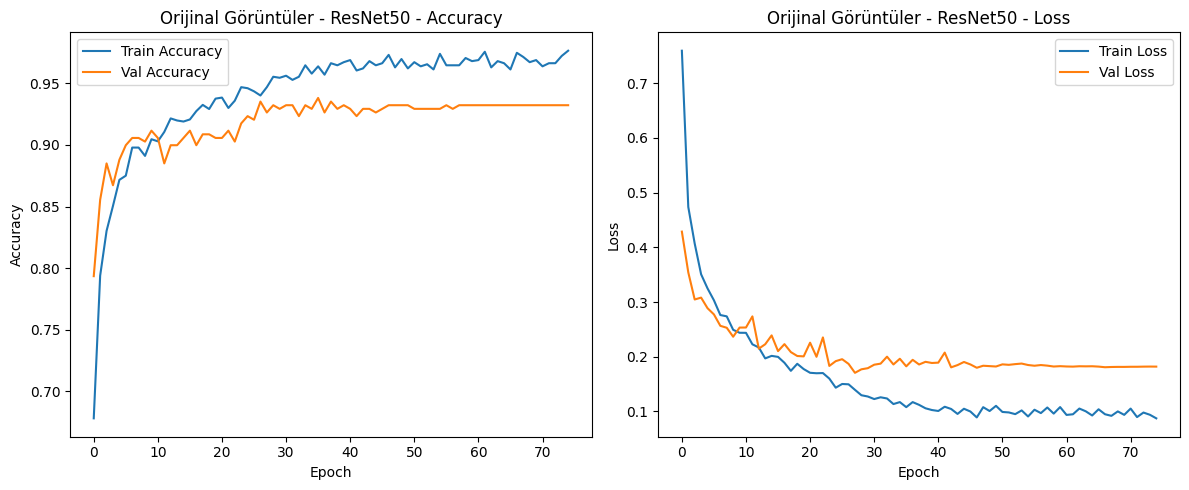

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 758ms/step

Orijinal Görüntüler - ResNet50 Sonuçları
Accuracy : 0.9235
Precision: 0.9252
Recall   : 0.9235
F1-Score : 0.9240

Classification Report:

              precision    recall  f1-score   support

      benign       0.86      0.91      0.88        55
   malignant       0.96      0.93      0.94       115

    accuracy                           0.92       170
   macro avg       0.91      0.92      0.91       170
weighted avg       0.93      0.92      0.92       170



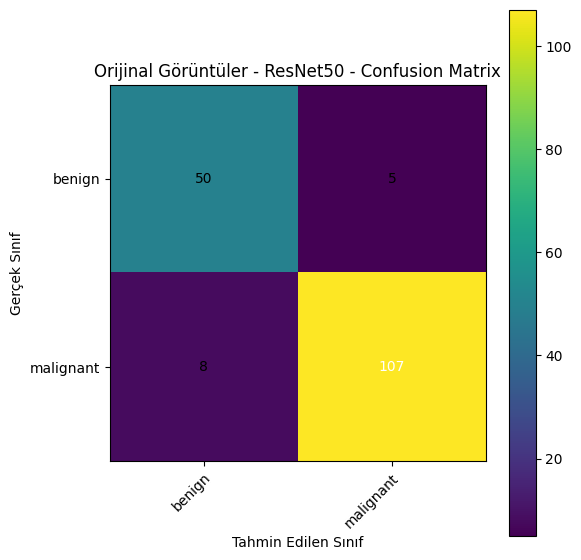

In [32]:
original_model, original_history, original_results = train_and_evaluate(
    ORIGINAL_DIR,
    "Orijinal Görüntüler - ResNet50"
)

In [34]:
import os

ORIGINAL_DIR = r"C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\archive"
FILTERED_DIR = r"C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset"

splits = ["train", "valid", "test"]
classes = ["benign", "malignant"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(FILTERED_DIR, split, cls), exist_ok=True)

print("filtered_dataset klasör yapısı oluşturuldu.")

filtered_dataset klasör yapısı oluşturuldu.


In [35]:
import cv2
import numpy as np

def apply_custom_filter(image_path):
    orijinal_img = cv2.imread(image_path)
    if orijinal_img is None:
        return None

    orijinal_rgb = cv2.cvtColor(orijinal_img, cv2.COLOR_BGR2RGB)

    # SCN-RDL'den esinlenilmiş H-benzeri çekirdek matrisi
    H_matrisi = orijinal_img[:, :, 1]
    H_norm = cv2.normalize(H_matrisi, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    gri_img = np.uint8(H_norm)

    # Ön işleme
    bilateral_img = cv2.bilateralFilter(gri_img, d=9, sigmaColor=75, sigmaSpace=75)
    blur_img = cv2.GaussianBlur(bilateral_img, (3, 3), 0)

    # Eşikleme
    _, otsu_maske = cv2.threshold(blur_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    adaptive_maske = cv2.adaptiveThreshold(
        blur_img, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    birlestirilmis_maske = cv2.bitwise_and(otsu_maske, adaptive_maske)
    ters_maske = cv2.bitwise_not(birlestirilmis_maske)

    # Morfolojik işlemler
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opening = cv2.morphologyEx(ters_maske, cv2.MORPH_OPEN, kernel, iterations=1)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    erozyon = cv2.erode(closing, kernel, iterations=1)
    genisletme = cv2.dilate(erozyon, kernel, iterations=1)

    # Kontur çizimi
    konturlar, _ = cv2.findContours(genisletme, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    gecerli_hucreler = [cnt for cnt in konturlar if cv2.contourArea(cnt) > 30]

    final_gorsel = orijinal_rgb.copy()
    cv2.drawContours(final_gorsel, gecerli_hucreler, -1, (0, 255, 0), 2)

    kirmizi_maske = np.zeros_like(orijinal_rgb)
    kirmizi_maske[:, :, 0] = genisletme  # RGB'de kırmızı kanal

    sonuc_blend = cv2.addWeighted(final_gorsel, 0.8, kirmizi_maske, 0.2, 0)

    # cv2.imwrite için tekrar BGR'ye çevir
    sonuc_bgr = cv2.cvtColor(sonuc_blend, cv2.COLOR_RGB2BGR)
    return sonuc_bgr

In [36]:
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

saved_count = 0
failed_files = []

for split in splits:
    for cls in classes:
        src_dir = os.path.join(ORIGINAL_DIR, split, cls)
        dst_dir = os.path.join(FILTERED_DIR, split, cls)

        for file_name in os.listdir(src_dir):
            if file_name.lower().endswith(valid_exts):
                src_path = os.path.join(src_dir, file_name)
                dst_path = os.path.join(dst_dir, file_name)

                filtered_img = apply_custom_filter(src_path)

                if filtered_img is not None:
                    cv2.imwrite(dst_path, filtered_img)
                    saved_count += 1
                else:
                    failed_files.append(src_path)

print(f"Toplam kaydedilen filtrelenmiş görüntü sayısı: {saved_count}")
print(f"Hatalı dosya sayısı: {len(failed_files)}")

Toplam kaydedilen filtrelenmiş görüntü sayısı: 1693
Hatalı dosya sayısı: 0


In [37]:
for split in splits:
    for cls in classes:
        folder = os.path.join(FILTERED_DIR, split, cls)
        print(folder, "->", len(os.listdir(folder)))

C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\train\benign -> 382
C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\train\malignant -> 802
C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\valid\benign -> 110
C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\valid\malignant -> 229
C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\test\benign -> 55
C:\Users\ehabr\OneDrive\Desktop\Bilgisayar Gormesi\odev 3\filtered_dataset\test\malignant -> 115


In [38]:
def create_generators_from_splits(base_dir):
    train_df = collect_split_paths(base_dir, "train", CLASS_NAMES)
    val_df   = collect_split_paths(base_dir, "valid", CLASS_NAMES)
    test_df  = collect_split_paths(base_dir, "test", CLASS_NAMES)

    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            "Train/valid/test veri çerçevelerinden en az biri boş. "
            "Klasör yollarını veya filtered_dataset içeriğini kontrol et."
        )

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=SEED
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col="filename",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [39]:
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

for split in splits:
    for cls in classes:
        orig_folder = os.path.join(ORIGINAL_DIR, split, cls)
        filt_folder = os.path.join(FILTERED_DIR, split, cls)

        orig_count = len([f for f in os.listdir(orig_folder) if f.lower().endswith(valid_exts)])
        filt_count = len([f for f in os.listdir(filt_folder) if f.lower().endswith(valid_exts)])

        print(f"{split} / {cls} -> original: {orig_count}, filtered: {filt_count}")

train / benign -> original: 382, filtered: 382
train / malignant -> original: 802, filtered: 802
valid / benign -> original: 110, filtered: 110
valid / malignant -> original: 229, filtered: 229
test / benign -> original: 55, filtered: 55
test / malignant -> original: 115, filtered: 115



Filtrelenmiş Görüntüler - ResNet50 için işlem başlıyor...
Found 1184 validated image filenames belonging to 2 classes.
Found 339 validated image filenames belonging to 2 classes.
Found 170 validated image filenames belonging to 2 classes.
Epoch 1/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 889ms/step - accuracy: 0.6343 - loss: 0.7904 - val_accuracy: 0.7257 - val_loss: 0.5865 - learning_rate: 1.0000e-04
Epoch 2/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 871ms/step - accuracy: 0.7188 - loss: 0.5603 - val_accuracy: 0.7965 - val_loss: 0.4756 - learning_rate: 1.0000e-04
Epoch 3/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 37s 989ms/step - accuracy: 0.7635 - loss: 0.4818 - val_accuracy: 0.8053 - val_loss: 0.4524 - learning_rate: 1.0000e-04
Epoch 4/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 36s 984ms/step - accuracy: 0.7753 - loss: 0.4885 - val_accuracy: 0.7847 - val_loss: 0.4640 - learning_rate: 1.0000e-04
Epoch 5/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 36s 980ms/step - accuracy: 0.8167 - loss: 0.4202 - val_accuracy: 0.8112 - val_loss: 0.4413 - l

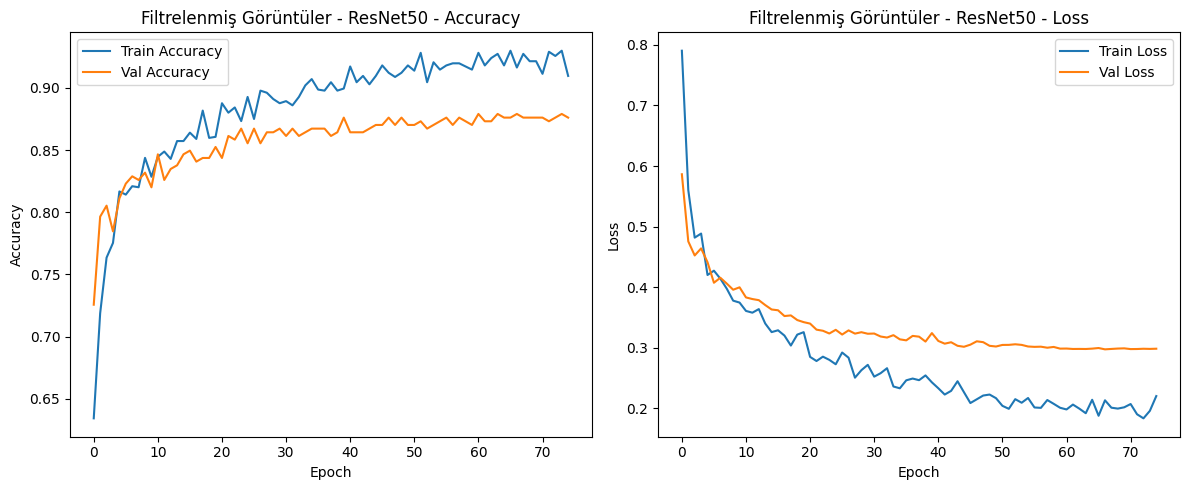

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 748ms/step

Filtrelenmiş Görüntüler - ResNet50 Sonuçları
Accuracy : 0.8824
Precision: 0.8815
Recall   : 0.8824
F1-Score : 0.8818

Classification Report:

              precision    recall  f1-score   support

      benign       0.83      0.80      0.81        55
   malignant       0.91      0.92      0.91       115

    accuracy                           0.88       170
   macro avg       0.87      0.86      0.86       170
weighted avg       0.88      0.88      0.88       170



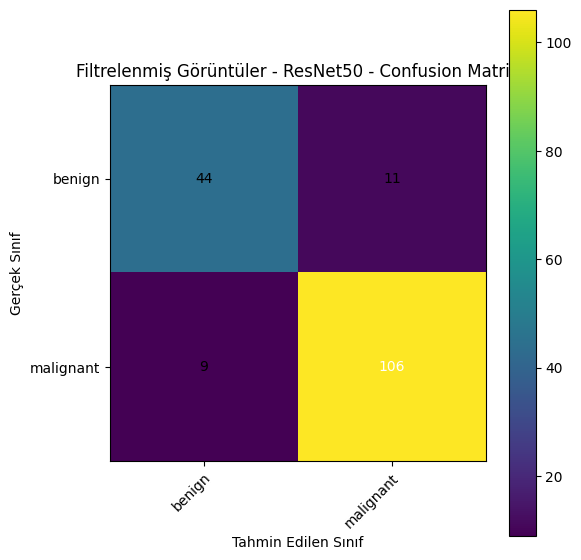

In [40]:
filtered_model, filtered_history, filtered_results = train_and_evaluate(
    FILTERED_DIR,
    "Filtrelenmiş Görüntüler - ResNet50"
)